In [25]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, '../src')
from model import build_design_matrix, fit_ols
from decomposition import decompose_revenue, calculate_media_roi

df = pd.read_csv("../data/processed/dt_transformed.csv")
df['DATE'] = pd.to_datetime(df['DATE'])

CHANNEL_LABELS = {
    'tv_S_adstock_norm_sat':        'TV',
    'ooh_S_adstock_norm_sat':       'OOH',
    'print_S_adstock_norm_sat':     'Print',
    'facebook_S_adstock_norm_sat':  'Facebook',
    'search_S_adstock_norm_sat':    'Search',
}

SAT_COLS = [
    'tv_S_adstock_norm_sat',
    'ooh_S_adstock_norm_sat',
    'print_S_adstock_norm_sat',
    'facebook_S_adstock_norm_sat',
    'search_S_adstock_norm_sat',
]

EXACT_WEEK_COLS = [f'is_week_{obs}' for obs in [25, 57, 73, 75, 109, 123]]

CONTROL_COLS = (
    ['competitor_sales_norm', 'is_holiday',
     'is_christmas', 'is_new_year', 'is_easter_monday', 'is_whit_monday', 'is_labor_day']
    + EXACT_WEEK_COLS
    + ['event1', 'event2',
       'February', 'March', 'May', 'June', 'July', 'August', 'September']
)

X = build_design_matrix(df, SAT_COLS, CONTROL_COLS)
y = df['revenue']
results = fit_ols(X, y)
print(f"Model re-fitted. R²={results.rsquared:.4f}")
print(f"Pure Baseline (intercept): £{results.params['const']:,.0f} per week")
print()

decomp = decompose_revenue(results, X, y, df['DATE'], SAT_COLS, CONTROL_COLS, CHANNEL_LABELS)
decomp.to_csv("../data/processed/decomposition.csv", index=False)
print(f"Saved decomposition.csv  ({decomp.shape[0]} rows × {decomp.shape[1]} cols)")
print()
decomp.head()

Model re-fitted. R²=0.9862
Pure Baseline (intercept): £1,653,893 per week

Saved decomposition.csv  (208 rows × 10 cols)



,DATE,TV,OOH,Print,Facebook,Search,Non-media Drivers,Baseline + Non-media,Fitted,Actual
0,2015-11-23,8789.678096,0.000000,95738.555135,28046.258923,0.000000,792134.603816,2.446027e+06,2.578602e+06,2.754372e+06
1,2015-11-30,38322.277465,0.000000,22224.198108,18606.392899,1566.518519,723711.145461,2.377604e+06,2.458323e+06,2.584277e+06
2,2015-12-07,11755.080429,25890.283935,9139.638774,25290.769587,1557.795834,845777.174399,2.499670e+06,2.573303e+06,2.547387e+06
3,2015-12-14,166770.353089,4785.981030,101975.409881,23129.069996,1585.192805,791483.622556,2.445376e+06,2.743622e+06,2.875220e+06
4,2015-12-21,76949.795810,58737.531244,31008.017608,13098.020118,1547.553217,581294.335107,2.235187e+06,2.416528e+06,2.215953e+06


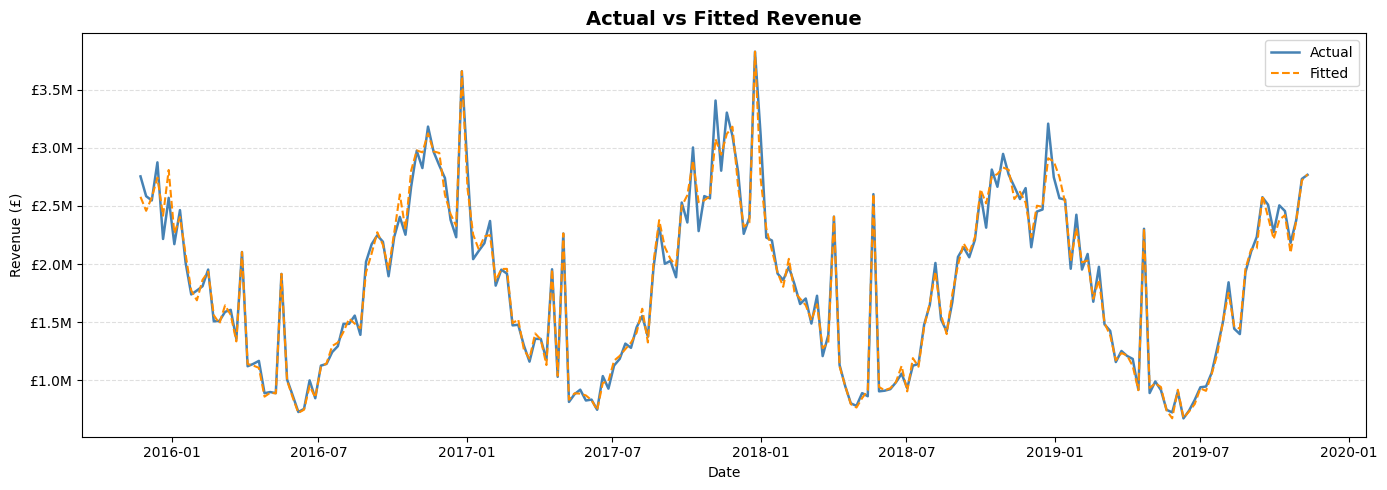

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(decomp['DATE'], decomp['Actual'], label='Actual', color='steelblue', linewidth=1.8)
ax.plot(decomp['DATE'], decomp['Fitted'], label='Fitted', color='darkorange', linewidth=1.5, linestyle='--')

ax.set_title('Actual vs Fitted Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/actual_vs_fitted.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
media_cols_labels = ['TV', 'OOH', 'Print', 'Facebook', 'Search']
total_fitted      = decomp['Fitted'].sum()

rows = {col: decomp[col].sum() for col in media_cols_labels}
rows['Non-media Drivers']  = decomp['Non-media Drivers'].sum()
rows['Pure Baseline']      = results.params['const'] * len(X)

totals  = pd.Series(rows)
pct     = totals / total_fitted * 100
summary = pd.DataFrame({'Total Revenue': totals.round(0), '% of Total': pct.round(1)})
print(summary)

                   Total Revenue  % of Total
TV                     8952892.0         2.4
OOH                    2328377.0         0.6
Print                  7384177.0         1.9
Facebook               2645983.0         0.7
Search                  307395.0         0.1
Non-media Drivers     13377228.0         3.5
Pure Baseline        344009645.0        90.8


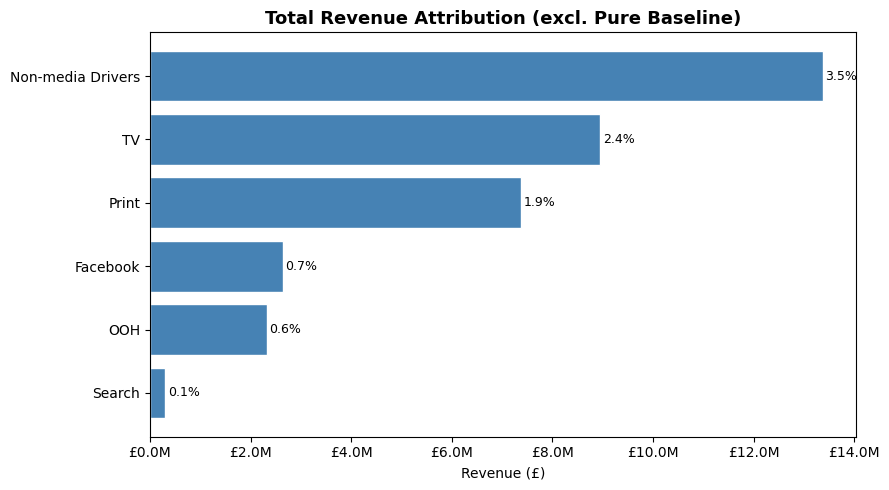

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

summary_plot = summary.drop(index='Pure Baseline').sort_values('Total Revenue', ascending=True)
bars = ax.barh(summary_plot.index, summary_plot['Total Revenue'],
               color='steelblue', edgecolor='white')

for bar, (_, row) in zip(bars, summary_plot.iterrows()):
    ax.text(bar.get_width() + 50000, bar.get_y() + bar.get_height() / 2,
            f"{row['% of Total']}%", va='center', fontsize=9)

ax.set_title('Total Revenue Attribution (excl. Pure Baseline)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (£)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/decomposition_attribution_bar.png', dpi=150, bbox_inches='tight')
plt.show()


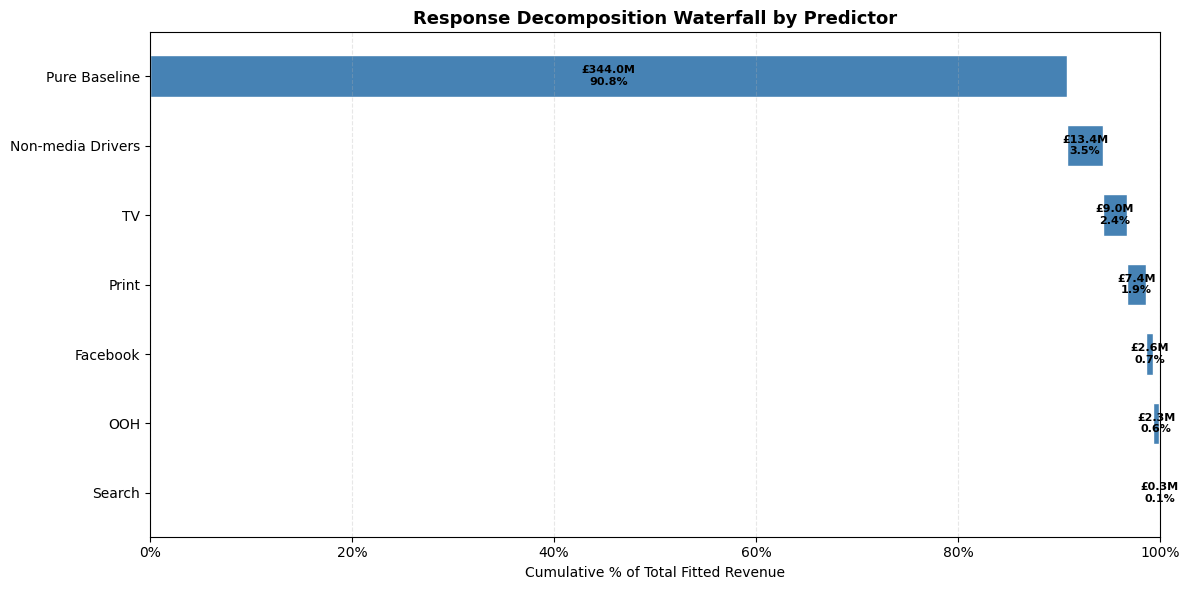

In [29]:
vol = summary.sort_values('% of Total', ascending=True).reset_index()
vol.columns = ['Predictor', 'Total Revenue', '% of Total']

# bars cascade from right to left (opposite side to y-axis labels)
vol['start'] = 100 - vol['% of Total'].cumsum()

fig, ax = plt.subplots(figsize=(12, 6))

for _, row in vol.iterrows():
    ax.barh(row['Predictor'], row['% of Total'], left=row['start'],
            color='steelblue', edgecolor='white', height=0.6)
    revenue_m = row['Total Revenue'] / 1e6
    label = f"£{revenue_m:.1f}M\n{row['% of Total']}%"
    ax.text(row['start'] + row['% of Total'] / 2, row['Predictor'],
            label, va='center', ha='center', fontsize=8, color='black', fontweight='bold')

ax.set_title('Response Decomposition Waterfall by Predictor', fontsize=13, fontweight='bold')
ax.set_xlabel('Cumulative % of Total Fitted Revenue')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/volume_contribution_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
df_raw = pd.read_csv("../data/raw/dt_simulated_weekly.csv")
df_raw = df_raw.sort_values('DATE').reset_index(drop=True)

MEDIA_COLS = ['tv_S', 'ooh_S', 'print_S', 'facebook_S', 'search_S']

MEDIA_CHANNEL_LABELS = {
    'tv_S':        'TV',
    'ooh_S':       'OOH',
    'print_S':     'Print',
    'facebook_S':  'Facebook',
    'search_S':    'Search',
}

roi_table = calculate_media_roi(decomp, df_raw, MEDIA_COLS, MEDIA_CHANNEL_LABELS)
print(roi_table.to_string(index=False))
roi_table.to_csv("../data/processed/roi_table.csv", index=False)

 Channel  Total Spend  Revenue Contribution  ROI
   Print     775556.0             7384177.0 9.52
Facebook     446297.0             2645983.0 5.93
      TV    3087488.0             8952892.0 2.90
     OOH    8989332.0             2328377.0 0.26
  Search    1230427.0              307395.0 0.25


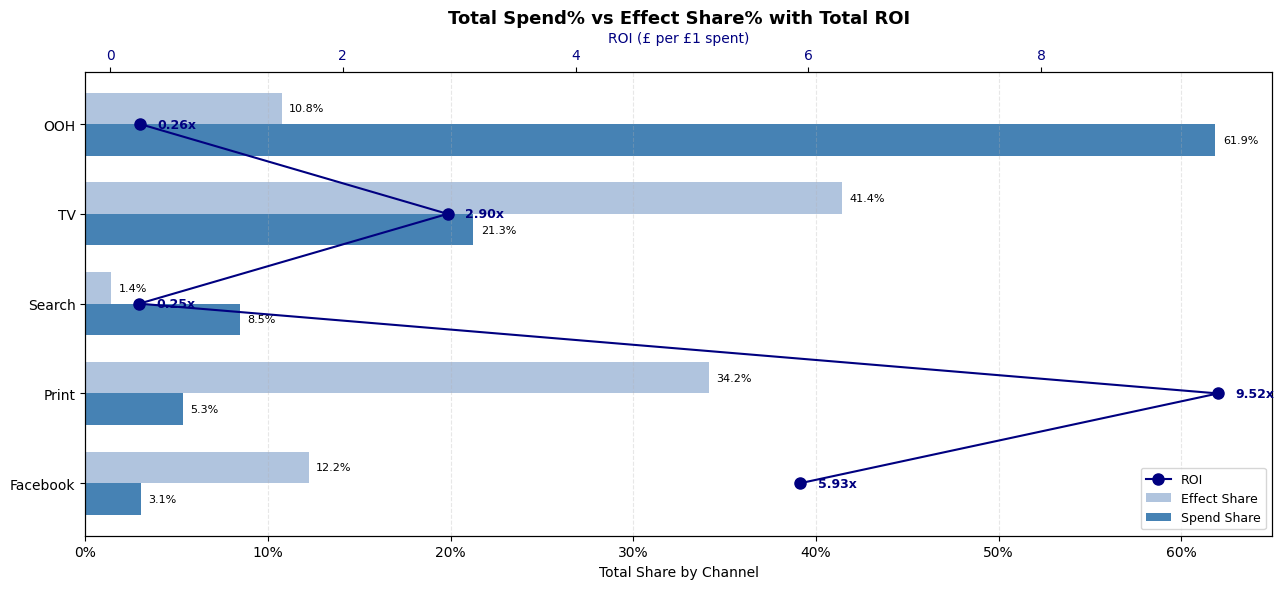

In [31]:
total_media_spend   = roi_table['Total Spend'].sum()
total_media_revenue = roi_table['Revenue Contribution'].sum()

roi_table['Spend Share']  = roi_table['Total Spend'] / total_media_spend * 100
roi_table['Effect Share'] = roi_table['Revenue Contribution'] / total_media_revenue * 100

plot_df = roi_table.sort_values('Spend Share', ascending=True).reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(13, 6))

y_pos  = np.arange(len(plot_df))
height = 0.35

ax1.barh(y_pos + height / 2, plot_df['Effect Share'], height=height,
         color='lightsteelblue', label='Effect Share')
ax1.barh(y_pos - height / 2, plot_df['Spend Share'], height=height,
         color='steelblue', label='Spend Share')

for i, row in plot_df.iterrows():
    ax1.text(row['Effect Share'] + 0.4, i + height / 2, f"{row['Effect Share']:.1f}%", va='center', fontsize=8)
    ax1.text(row['Spend Share']  + 0.4, i - height / 2, f"{row['Spend Share']:.1f}%",  va='center', fontsize=8)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_df['Channel'])
ax1.set_xlabel('Total Share by Channel')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.grid(axis='x', linestyle='--', alpha=0.3)

ax2 = ax1.twiny()
ax2.plot(plot_df['ROI'], y_pos, 'o-', color='navy', linewidth=1.5, markersize=8, label='ROI')
for i, row in plot_df.iterrows():
    ax2.text(row['ROI'] + 0.15, i, f"{row['ROI']:.2f}x", va='center', fontsize=9,
             color='navy', fontweight='bold')
ax2.set_xlabel('ROI (£ per £1 spent)', color='navy')
ax2.tick_params(axis='x', labelcolor='navy')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h2 + h1, l2 + l1, loc='lower right', fontsize=9)

ax1.set_title('Total Spend% vs Effect Share% with Total ROI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/spend_vs_effect_roi.png', dpi=150, bbox_inches='tight')
plt.show()

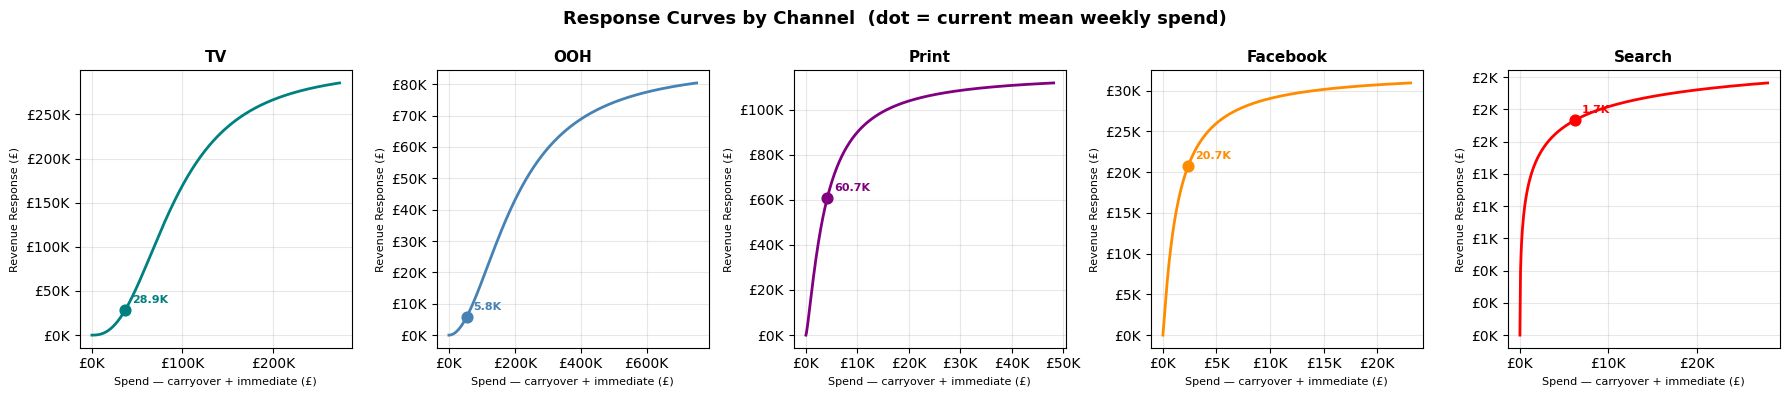

In [35]:
from transformations import geometric_adstock, hill_saturation

PARAMS = {
    'tv_S':       {'decay': 0.60, 'K': 0.50, 'S': 2.5},
    'ooh_S':      {'decay': 0.20, 'K': 0.40, 'S': 2.0},
    'print_S':    {'decay': 0.10, 'K': 0.12, 'S': 1.3},
    'facebook_S': {'decay': 0.09, 'K': 0.09, 'S': 1.1},
    'search_S':   {'decay': 0.05, 'K': 0.05, 'S': 0.5},
}

COEF_MAP = {
    'tv_S':       results.params['tv_S_adstock_norm_sat'],
    'ooh_S':      results.params['ooh_S_adstock_norm_sat'],
    'print_S':    results.params['print_S_adstock_norm_sat'],
    'facebook_S': results.params['facebook_S_adstock_norm_sat'],
    'search_S':   results.params['search_S_adstock_norm_sat'],
}

COLORS = {
    'tv_S': 'teal', 'ooh_S': 'steelblue', 'print_S': 'purple',
    'facebook_S': 'darkorange', 'search_S': 'red'
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, MEDIA_COLS):
    decay = PARAMS[col]['decay']
    K     = PARAMS[col]['K']
    S     = PARAMS[col]['S']
    coef  = COEF_MAP[col]
    color = COLORS[col]
    label = MEDIA_CHANNEL_LABELS[col]

    actual_adstock = geometric_adstock(df_raw[col].values, decay)
    max_adstock    = actual_adstock.max()

    adstock_range = np.linspace(0, max_adstock * 1.5, 400)
    norm_range    = adstock_range / max_adstock
    response      = coef * hill_saturation(norm_range, K=K, S=S)

    mean_adstock  = actual_adstock.mean()
    mean_norm     = mean_adstock / max_adstock
    mean_response = coef * hill_saturation(np.array([mean_norm]), K=K, S=S)[0]

    ax.plot(adstock_range, response, color=color, linewidth=2)
    ax.scatter([mean_adstock], [mean_response], color=color, s=60, zorder=5)
    ax.annotate(f"{mean_response/1000:.1f}K",
                xy=(mean_adstock, mean_response),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, color=color, fontweight='bold')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Spend — carryover + immediate (£)', fontsize=8)
    ax.set_ylabel('Revenue Response (£)', fontsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1000:.0f}K'))
    ax.grid(alpha=0.3)

fig.suptitle('Response Curves by Channel  (dot = current mean weekly spend)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/response_curves.png', dpi=150, bbox_inches='tight')
plt.show()

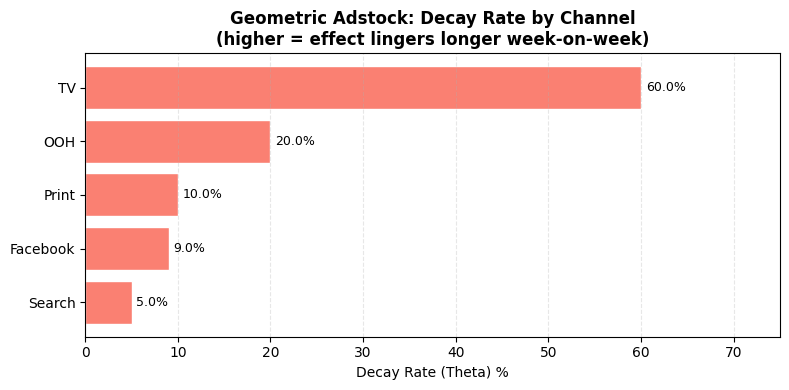

In [38]:
decay_rates = {MEDIA_CHANNEL_LABELS[col]: PARAMS[col]['decay'] * 100 for col in MEDIA_COLS}
decay_df    = pd.Series(decay_rates).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(decay_df.index, decay_df.values, color='salmon', edgecolor='white')

for bar, val in zip(bars, decay_df.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=9)

ax.set_title('Geometric Adstock: Decay Rate by Channel\n(higher = effect lingers longer week-on-week)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Decay Rate (Theta) %')
ax.set_xlim(0, max(decay_df.values) * 1.25)
ax.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/decomposition_plots/adstock_decay_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
total_media_spend    = df_raw[MEDIA_COLS].sum().sum()
total_actual_revenue = decomp['Actual'].sum()
total_fitted_revenue = decomp['Fitted'].sum()

print(f"Total media spend:    £{total_media_spend:,.0f}")
print(f"Total actual revenue: £{total_actual_revenue:,.0f}")
print(f"Total fitted revenue: £{total_fitted_revenue:,.0f}")

Total media spend:    £14,529,099
Total actual revenue: £379,005,697
Total fitted revenue: £379,005,697



My advice on budget reallocation based on the model interpretation above:

**Reduce:**

* OOH — cut spend significantly. 61.9% of budget for 10.8% effect share and 0.28x ROI is indefensible from a pure performance standpoint. The only caveat is the brand-building argument, which needs brand tracking data to validate before making the final call.<br>
* Search — reduce but don't eliminate. You need minimum presence for visibility, but the current allocation is losing money. Audit the keyword strategy first.

**Maintain cautiously:**

* Print — keep current spend but don't increase aggressively. Best ROI in the mix but the response curve says the ceiling is near. Modest increases only.<br>
* Facebook — same story. Good ROI but already in diminishing returns territory. Don't push more in.

**Increase:**

* TV — the clearest opportunity. Still on the steep part of its curve, 2.88x ROI, and already driving 40.8% of media revenue. More spend here should still yield strong returns.

**Summary:**

The budget freed from OOH and Search should go primarily to TV, with small increments tested on Print and Facebook to see how quickly their ROI deteriorates.

The one thing I'd add that you didn't mention — all of this should be tested incrementally, not implemented all at once. MMM tells you the direction, not the exact optimal amount. You'd run budget experiments and re-estimate the model to validate.